# ◉ Dimensions & Embeddings

### add the notes image

## Bigram Model
remember the next word prediction on your phone

![bigram](./_asset/gpt/bigram_3.png)


## add notes from manta

### Training a character bigram model on 32k english names dataset

In [1]:
words = open('names.txt', 'r').read().splitlines()
print(f"first 10 names from dataset {words[:10]}")
print(f"Length of dataset {len(words)}")
print(f"Smallest name size {min(len(w) for w in words)}")
print(f"longest name size {max(len(w) for w in words)}")

first 10 names from dataset ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Length of dataset 32033
Smallest name size 2
longest name size 15


How would we create character pairs from single name?

```
name = 'John' and name[1:] = 'ohn'
zip(name, name[1:]) = [('J', 'o'), ('o', 'h'), ('h', 'n')]
```

In [3]:
name = 'John'
for ch1, ch2 in zip(name, name[1:]): 
    print(ch1, ch2)


J o
o h
h n


... and finally attach a character token to indicate start and end of the name along with a count to indicate the number of times the pair appeared in the text (single word).

In [ ]:
# Function to build character bigram model with the start and end tokens
# count the number of times each bigram appears in the list of words
def create_char_bigram_model(words):
    bigram_model = {}
    for w in words:
        chs = ['<S>'] + list(w) + ['<E>']
        for ch1, ch2 in zip(chs, chs[1:]):
            bigram = (ch1, ch2)
            bigram_model[bigram] = bigram_model.get(bigram, 0) + 1
    return bigram_model

def sort(bigram_model):
    return sorted(bigram_model.items(), key = lambda kv: -kv[1])

In [5]:
name = 'John'
respone = create_char_bigram_model([name])
sort(respone)

[(('<S>', 'J'), 1),
 (('J', 'o'), 1),
 (('o', 'h'), 1),
 (('h', 'n'), 1),
 (('n', '<E>'), 1)]

Creating character bigrams from the names dataset and displaying the top 10 most common pairs of characters.

In [7]:
bigram_model = create_char_bigram_model(words)
sort(bigram_model)[:10]

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

In [8]:
import torch

A 27x27 tensor to represent the bigrams i.e. it will hold the count of each character pair where the i represents the first character and j represents the second character. Note that we are using . as the start and end token.

In [9]:
# 26 Charaacters in the alphabet + . (token to indicate start and end of word)
# create a tensor of 27x27 to store the bigram counts
N = torch.zeros((27, 27), dtype=torch.int32)

our characters would be indexed as integers from 1 to 27. We'll reserve 0 to represent the padding token (start and end char).

In [2]:
chars = sorted(list(set(''.join(words))))
# s (str) to i (index)
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
# rever the array
itos = {i:s for s,i in stoi.items()}

print(f"stoi['a'] = {stoi['a']}")
print(f"itos[1] = {itos[1]}")

stoi['a'] = 1
itos[1] = a


In [11]:

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

print(f"N[stoi['a'], stoi['n']] = count of 'a' and 'n' = {N[stoi['a'], stoi['n']]}")

N[stoi['a'], stoi['n']] = count of 'a' and 'n' = 5438


### Character Bigrams model represented as 27x27 tensor

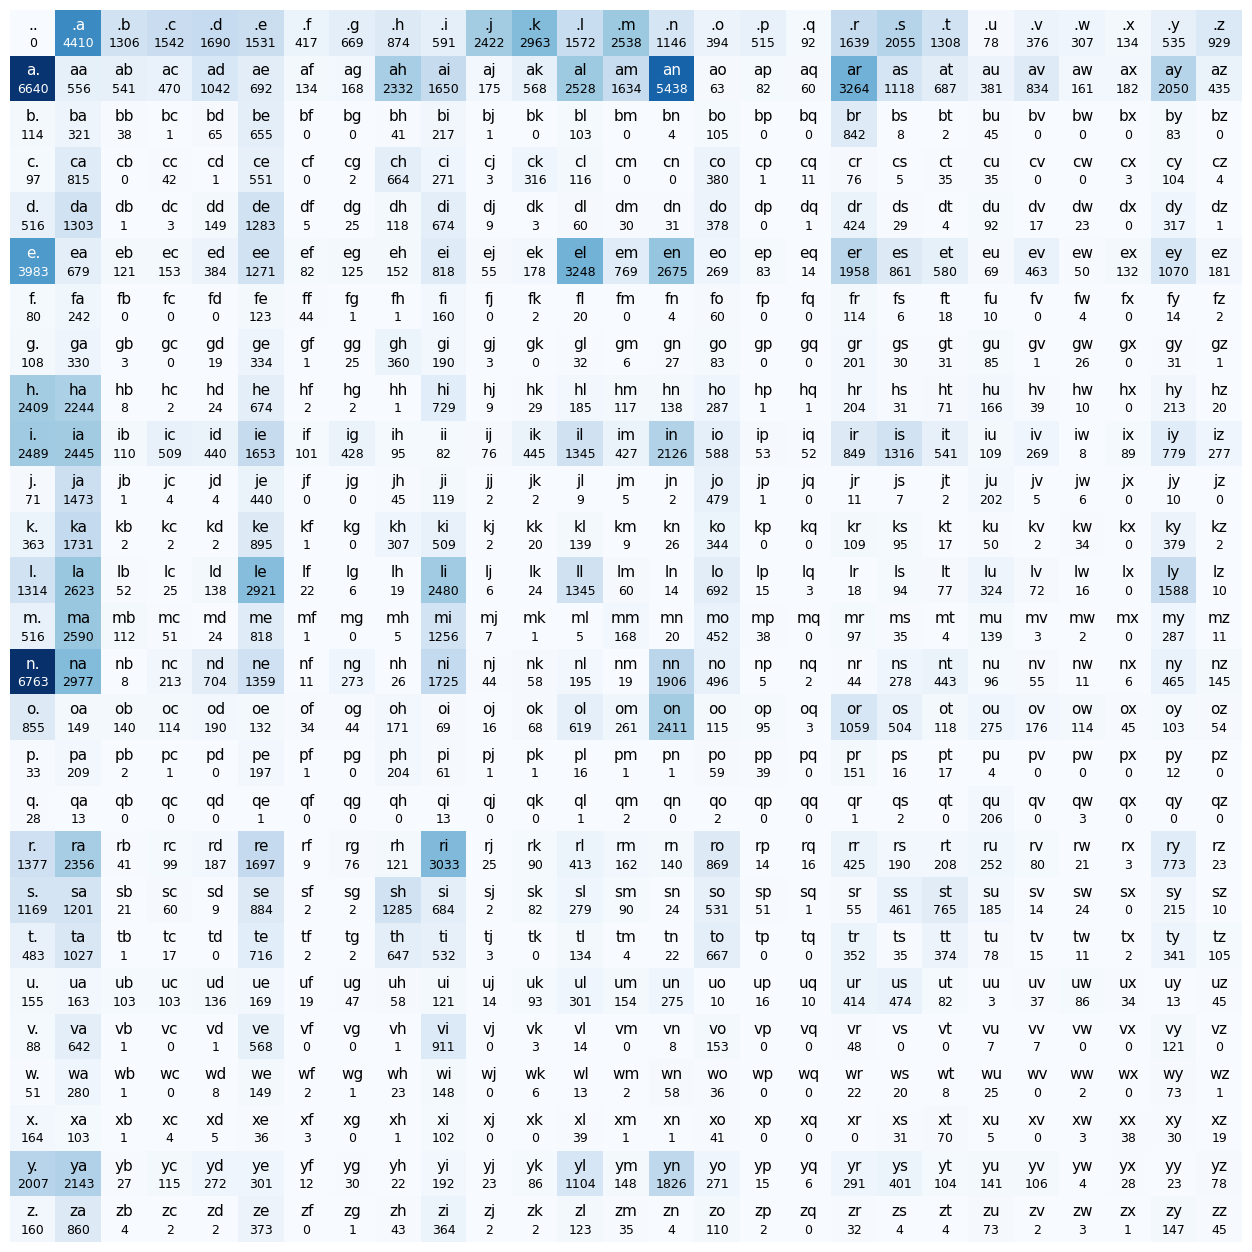

In [41]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        color = 'white' if N[i, j].item() > N.max().item() / 2 else 'black'
        plt.text(j, i , chstr, ha="center", va="bottom", color=color, fontsize=11)
        plt.text(j, i + 0.1, N[i, j].item(), ha="center", va="top", color=color, fontsize=9)
plt.axis('off');

In [22]:
name = 'john'
chs = ['.'] + list(name) + ['.']
print("Bigram counts for 'john':")
for ch1, ch2 in zip(chs, chs[1:]):
    ix1, ix2 = stoi[ch1.lower()], stoi[ch2.lower()]
    count = N[ix1, ix2].item()
    print(f"  P( {ch2.lower()} | {ch1.lower()} ) = {count}")

print("\nNext 3 characters after 'J':")
predicted = ['j']
g = torch.Generator().manual_seed(2147483647)
ix = stoi['j']
for step in range(3):
    p = N[ix].float()
    p = p / p.sum()
    next_ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    count = N[ix, next_ix].item()
    print(f"  Pred {step+1}: '{itos[ix]}' -> '{itos[next_ix]}' (count: {count})")
    predicted.append(itos[next_ix])
    ix = next_ix

print(f"\nWhat bigram would predict: {''.join(predicted)}")

Bigram counts for 'john':
  P( j | . ) = 2422
  P( o | j ) = 479
  P( h | o ) = 171
  P( n | h ) = 138
  P( . | n ) = 6763

Next 3 characters after 'J':
  Pred 1: 'j' -> 'a' (count: 1473)
  Pred 2: 'a' -> 'e' (count: 692)
  Pred 3: 'e' -> 'x' (count: 132)

What bigram would predict: jaex


### Generating names based on probability distribution
Given our probability distribution, we can sample the next character based on the likelihood of each character following the previous one.

In [42]:
N[0] # equal to N[0, :]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

Convert sum into row-wise probability distribution

In [45]:
g = torch.Generator().manual_seed(2147483647)

P = N.float()
# P = P / P.sum(1, keepdim=True)  # Creates new tensor and not memory efficient
P /= P.sum(1, keepdim=True) # creates in-place and is memory efficient
P[0, :].sum() # should normalise to 1
print(f'Probability distribution of first row \n{P[1, :]}')
print(f'And it sum up to = {P[1, :].sum()}')

Probability distribution of first row 
tensor([0.1960, 0.0164, 0.0160, 0.0139, 0.0308, 0.0204, 0.0040, 0.0050, 0.0688,
        0.0487, 0.0052, 0.0168, 0.0746, 0.0482, 0.1605, 0.0019, 0.0024, 0.0018,
        0.0963, 0.0330, 0.0203, 0.0112, 0.0246, 0.0048, 0.0054, 0.0605, 0.0128])
And it sum up to = 1.0


##### Generate 10 new names

In [ ]:
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


## Alternate appraoch of building character bigrams using neural net

##### Input to NN: **one-hot encoding** format to represent each caracter as catagorical feature
each character can be represented by a vector of shape 27

* The index corresponding to the character is set to **1**.
* All other indices are set to **0**.

#### Input: \<S> e m m a \<E>

One-hot shape: torch.Size([5, 27])


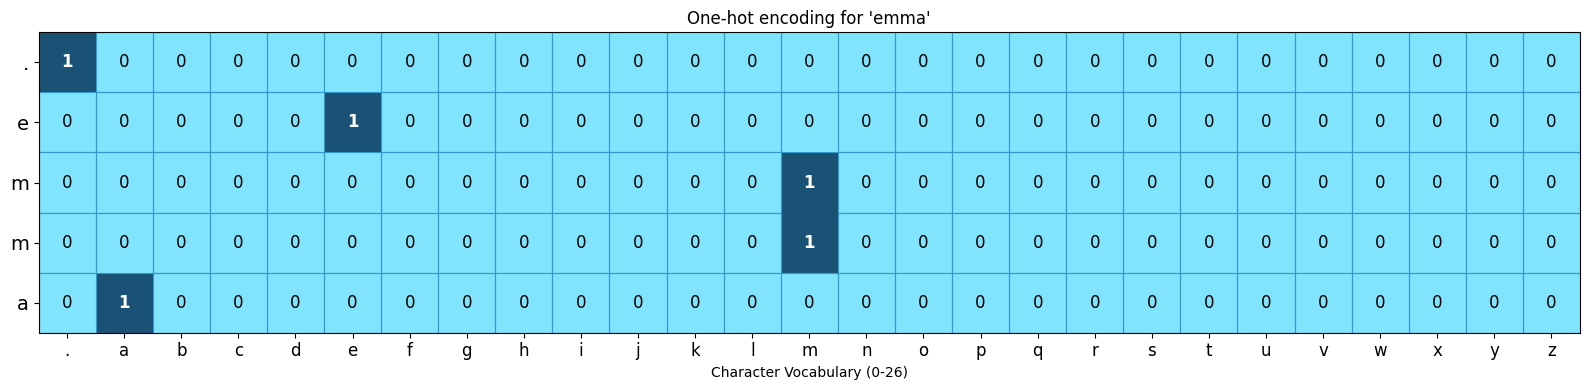

In [70]:
from matplotlib.colors import ListedColormap

from matplotlib.patches import Rectangle
import torch.nn.functional as F
xs_emma, ys_emma = [], []
name = 'emma'
chs = ['.'] + list(name) + ['.']
for ch1, ch2 in zip(chs, chs[1:]):
    xs_emma.append(stoi[ch1])
    ys_emma.append(stoi[ch2])

xs_emma = torch.tensor(xs_emma)
ys_emma = torch.tensor(ys_emma)

xenc_emma = F.one_hot(xs_emma, num_classes=27).float()
print(f"One-hot shape: {xenc_emma.shape}") 

cmap = ListedColormap(["#81E4FD", '#1A5276']) 

n_rows = xenc_emma.shape[0]  # 5, not 6

fig, ax = plt.subplots(figsize=(16, 4))
ax.imshow(xenc_emma, cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(27))
ax.set_xticklabels([itos[i] for i in range(27)], fontsize=12)
ax.set_yticks(range(n_rows))
ax.set_yticklabels([itos[i.item()] for i in xs_emma], fontsize=14)  # 5 input chars

for row in range(n_rows):  # fixed: 5 iterations, not 6
    for col in range(27):
        val = int(xenc_emma[row, col].item())
        if val == 1:
            ax.text(col, row, '1', ha='center', va='center', color='white', fontweight='bold', fontsize=12)
        else:
            ax.add_patch(Rectangle((col - 0.5, row - 0.5), 1, 1,
                                    fill=False, edgecolor='#3399CC', linewidth=0.8))
            ax.text(col, row, '0', ha='center', va='center', color='#000000', fontsize=12)

ax.set_xlabel('Character Vocabulary (0-26)')
ax.set_title("One-hot encoding for 'emma'")
plt.tight_layout()
plt.show()

#### model weights
A random weight matrix that will eventually learn the 27x27 probability count based tensor

In [91]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [92]:
xs_emma

tensor([ 0,  5, 13, 13,  1])

In [93]:
ys_emma

tensor([ 5, 13, 13,  1,  0])

- Input `emma` to the network as one-hot encoding (shape: [5, 27])
- Dot product with weight matrix W to produce raw scores (log-counts)
- Apply softmax (exponentiate + normalize to probabilities) to get probability distribution across 27 possible next characters

In [94]:
xenc = F.one_hot(xs_emma, num_classes=27).float() 
logits = xenc @ W # predict log-counts
counts = logits.exp()

# Softmax Activation
probs = counts / counts.sum(1, keepdims=True)

In [95]:
probs.shape

torch.Size([5, 27])

In [96]:
def get_model_confidence(nlls):
    avg_nll = nlls.mean().item()
    loss = torch.tensor(avg_nll)
    avg_prob = torch.exp(-loss)
    return (avg_prob * 100).item()

Run the network for the word `emma`

In [97]:
nlls = torch.zeros(5)
for i in range(5):
  x = xs_emma[i].item()
  y = ys_emma[i].item()
  print('--------')
  print(f'Bigram sample {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')

print('average negative log likelihood, i.e. loss =', nlls.mean().item())
print(f"models confidence: {get_model_confidence(nlls):.2f}%")

--------
Bigram sample 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
Bigram sample 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
       grad_fn=<SelectBackward0>)
label (actual next character): 1

In [ ]:
for i in range(5):
    print('======== iteration ', i)
    # forward pass
    xenc = F.one_hot(xs_emma, num_classes=27).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

    # calculate loss
    loss = -probs[torch.arange(5), ys_emma].log().mean()
    print(f"loss = {loss.item()}")
    print(f'models confidence = {get_model_confidence(loss):.2f}%')

    # backward pass
    W.grad = None
    loss.backward()

    # Updating the weights with small learning rate (graidient descent)
    W.data += -0.1 * W.grad
    print('======== END ', i)


======== iteration  0
loss = 3.7693049907684326
models confidence = 2.31%
======== END  0
======== iteration  1
loss = 3.7492129802703857
models confidence = 2.35%
======== END  1
======== iteration  2
loss = 3.7291626930236816
models confidence = 2.40%
======== END  2
======== iteration  3
loss = 3.7091541290283203
models confidence = 2.45%
======== END  3
======== iteration  4
loss = 3.6891887187957764
models confidence = 2.50%
======== END  4


#### Run the forward pass on names dataset

In [ ]:
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print("e.g. for the word 'emma' we have 5 bigrams: .e, em, mm, ma, a. samples")
print('number of samples: ', num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

e.g. for the word 'emma' we have 5 bigrams: .e, em, mm, ma, a. samples
number of samples:  228146


In [ ]:
def train(n, iteration):
  for k in range(n):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    
    if (k == 1):
      print(f'loss = {loss.item()} before iteration {iteration}')
    # backward pass
    W.grad = None # set to zero the gradient
    loss.backward()
    
    # update
    W.data += -50 * W.grad
  print(f'loss = {loss.item()} after iteration {iteration}')

train(100, 1)
train(100, 2)
train(100, 3)
train(100, 4)
train(100, 5)

loss = 3.3788068294525146 before iteration 1
loss = 2.4901304244995117 after iteration 1
loss = 2.4897916316986084 before iteration 2
loss = 2.4829957485198975 after iteration 2
loss = 2.4829440116882324 before iteration 3
loss = 2.4815075397491455 after iteration 3
loss = 2.4814915657043457 before iteration 4
loss = 2.480978012084961 after iteration 4
loss = 2.480971336364746 before iteration 5
loss = 2.480738878250122 after iteration 5


In [ ]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  
  out = []
  samples = 0
  while True:
    xenc = F.one_hot(torch.tensor([samples]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    samples = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[samples])
    if samples == 0:
      break
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


## ADD manta NOTES on ngram

## 4-gram character model
A 4-gram model takes three input characters (context = 3) and predicts the next one

i.e. there are **19,683 unique contexts** i.e. $27^3 = 19,683$.

#### representing input character sequence as tokens
convert the 3-character context into a single integer i.e. treat the 3 characters as a base-27 number.

$$
\boxed{
\text{ID} = \text{index}(c_0) \cdot 27^2 + \text{index}(c_1) \cdot 27 + \text{index}(c_2)
}
$$

where $c_0$, $c_1$, and $c_2$ are the three characters in the context. The index of each character is its position in the vocabulary (of size 27), including a special padding character (".") at index 0.

![nn_bigram](./_asset/gpt/bigram_4.png)



In [ ]:
xs, ys = [], []
for w in ["emma"]:
    chs = ['.'] + list(w) + ['.']
    for i in range(len(chs) - 3):
        print(f'----sample {i+1} ----------------------')
        context = chs[i:i+3]  # 3-character window
        print(f'input sequence: {context}')
        target = chs[i+3]
        print(f'expected output: {target}')
        # Convert context to a unique integer (0 to 27³-1)
        ix_context = stoi[context[0]] * 27**2 + stoi[context[1]] * 27 + stoi[context[2]]
        print(f'unique number for {context} sequence: {ix_context}')
        ix_target = stoi[target]
        xs.append(ix_context)
        ys.append(ix_target)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of samples in "emma":', num)

----sample 1 ----------------------
input sequence: ['.', 'e', 'm']
expected output: m
unique number for ['.', 'e', 'm'] sequence: 148
----sample 2 ----------------------
input sequence: ['e', 'm', 'm']
expected output: a
unique number for ['e', 'm', 'm'] sequence: 4009
----sample 3 ----------------------
input sequence: ['m', 'm', 'a']
expected output: .
unique number for ['m', 'm', 'a'] sequence: 9829
number of samples in "emma": 3


- The first character (context[0]) is the most significant digit, so it's multiplied by 27 squared (27^2). 
- The second character (context[1]) is multiplied by 27^1
- The third character (context[2]) is multiplied by 27^0, which is 1. 
Adding these products together gives a unique integer for every unique combination of the three characters. This ensures every possible 3-character combination gets a **unique integer ID** between 0 and \(27^3 - 1 = 19,682\).

> For example, if the characters are 'a', 'b', 'c' with indices 1, 2, 3 respectively, the calculation would be $$1 \cdot 27^2 + 2 \cdot 27^1 + 3 \cdot 1 = 729 + 54 + 3 = 786$$

#### Create 3 char samples from names dataset

In [5]:
import time

xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for i in range(len(chs) - 3):
        context = chs[i:i+3]  
        target = chs[i+3]
        ix_context = stoi[context[0]] * 27**2 + stoi[context[1]] * 27 + stoi[context[2]]
        ix_target = stoi[target]
        xs.append(ix_context)
        ys.append(ix_target)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(xs.unique().shape)
print('number of samples in extracted from names dataset :', num)

torch.Size([5659])
number of samples in extracted from names dataset : 164080


### add the notes image

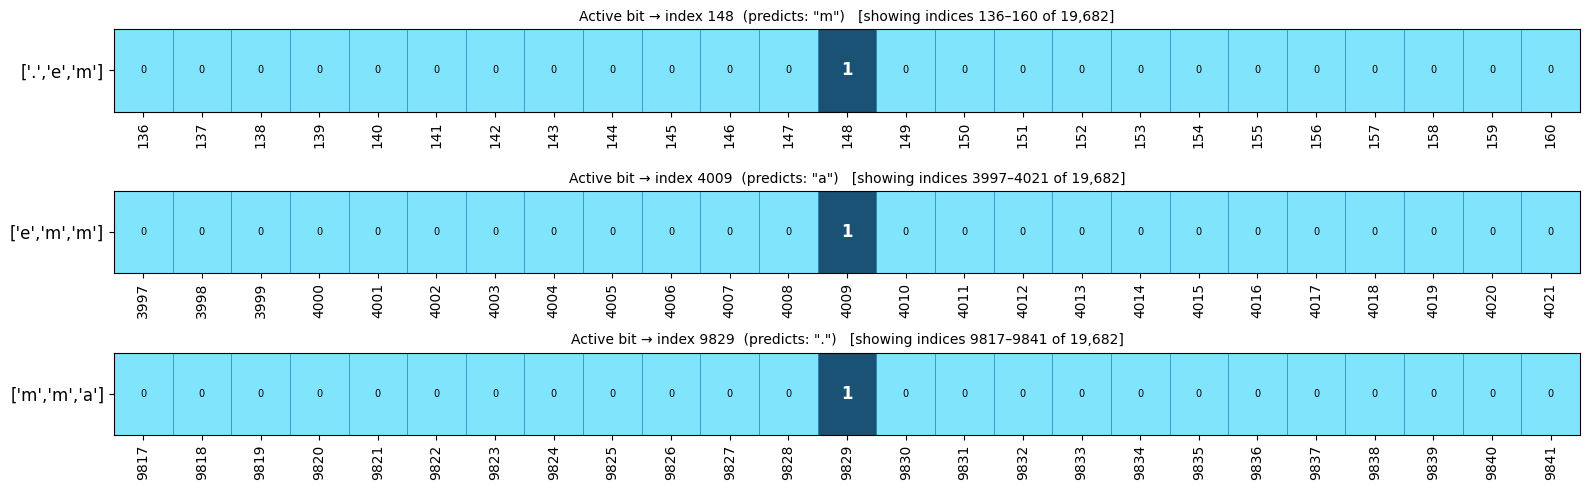

In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

xenc_4gram = F.one_hot(xs, num_classes=27**3).float()

samples_info = [
    (xs[0].item(), "['.','e','m']", 'm'),
    (xs[1].item(), "['e','m','m']", 'a'),
    (xs[2].item(), "['m','m','a']", '.'),
]

window = 12  # show ±12 indices around the active bit

fig, axes = plt.subplots(3, 1, figsize=(16, 5))
cmap = ListedColormap(["#81E4FD", '#1A5276'])

for ax, (active_idx, context_label, target) in zip(axes, samples_info):
    start = max(0, active_idx - window)
    end   = min(27**3, active_idx + window + 1)
    indices = list(range(start, end))
    
    # slice one-hot vector to the window
    row_slice = xenc_4gram[samples_info.index((active_idx, context_label, target)), start:end].unsqueeze(0)
    
    ax.imshow(row_slice, cmap=cmap, aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(indices)))
    ax.set_xticklabels(indices, rotation=90, fontsize=10)
    ax.set_yticks([0])
    ax.set_yticklabels([context_label], fontsize=12)
    ax.set_title(f'Active bit → index {active_idx}  (predicts: "{target}")   [showing indices {start}–{end-1} of 19,682]', fontsize=10)
    
    # annotate the active '1'
    local = active_idx - start
    ax.text(local, 0, '1', ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    for i in range(len(indices)):
        if i != local:
            ax.add_patch(Rectangle((i-0.5, -0.5), 1, 1, fill=False, edgecolor='#3399CC', linewidth=0.5))
            ax.text(i, 0, '0', ha='center', va='center', color='black', fontsize=7)

plt.tight_layout()
plt.show()

#### Training the 4-gram model on 32k names dataset
>executed on NVIDIA 5090

In [6]:
import torch
import torch.nn.functional as F
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27**3, 27), generator=g, requires_grad=True)  # Shape [19683, 27]

def train(n, iteration):
    for k in range(n):
        start_time = time.time()
        # forward pass
        xenc = F.one_hot(xs, num_classes=27**3).float()  # Shape [164080, 19683]
        logits = xenc @ W  # Shape [164080, 27]
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
        
        # Backward pass and update
        W.grad = None
        loss.backward()

        # Update weights
        W.data += -50 * W.grad

        end_time = time.time()
        print(f'iteration {k+1} took {end_time - start_time:.2f} seconds')
    
    print(f'loss = {loss.item()} after training set {iteration}')

train(20, 1)

iteration 1 took 2.69 seconds
iteration 2 took 2.72 seconds
iteration 3 took 2.69 seconds
iteration 4 took 2.68 seconds
iteration 5 took 2.68 seconds
iteration 6 took 2.70 seconds
iteration 7 took 2.69 seconds
iteration 8 took 2.69 seconds
iteration 9 took 2.70 seconds
iteration 10 took 2.67 seconds
iteration 11 took 2.69 seconds
iteration 12 took 2.70 seconds
iteration 13 took 2.67 seconds
iteration 14 took 2.68 seconds
iteration 15 took 2.68 seconds
iteration 16 took 2.68 seconds
iteration 17 took 2.68 seconds
iteration 18 took 2.70 seconds
iteration 19 took 2.72 seconds
iteration 20 took 2.69 seconds
loss = 3.461707353591919 after training set 1


#### Generate Names

In [7]:
for i in range(10):
  
  out = []
  samples = 0
  while True:
    xenc = F.one_hot(torch.tensor([samples]), num_classes=27**3).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    samples = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[samples])
    if samples == 0:
      break
  print(''.join(out))

ozaltiygkbvmfhsy.
pbogmup.
rajqxedbvbuzwdbterdkriirejkmc.
pxjszwtognw.
phwmklecvogwptjw.
oqr.
trzikluuiqtgkpjluipalrh.
zsvwiisxlppohufpblvkhwdwmywpajwkkgkfuyu.
gdctktprqoafyypcccnabmunvloc.
fpjqbwrfbmalpbcjqxjmxc.


In [8]:
print('Total number of samples from names dataset :', num)
print(f'Unique 3 character sequence: {xs.unique().nelement()}')
print(f'No of unique sequences model have not seen: {num - xs.unique().nelement()}')

Total number of samples from names dataset : 164080
Unique 3 character sequence: 5659
No of unique sequences model have not seen: 158421


With a dataset of 32,000 names, we could barely generate 5659 unique sequence or tokens. Which means that the model have yet to learn on the remainder of 158421 possible sequences.

- One-hot representation (categorical features) is very sparse and memory heavy
- such high dimensional space (19,683) would hurt generalization e.g. even with 32k names, we could barely generate 5.6k unique 3-character contexts
- the network is computationally heavy

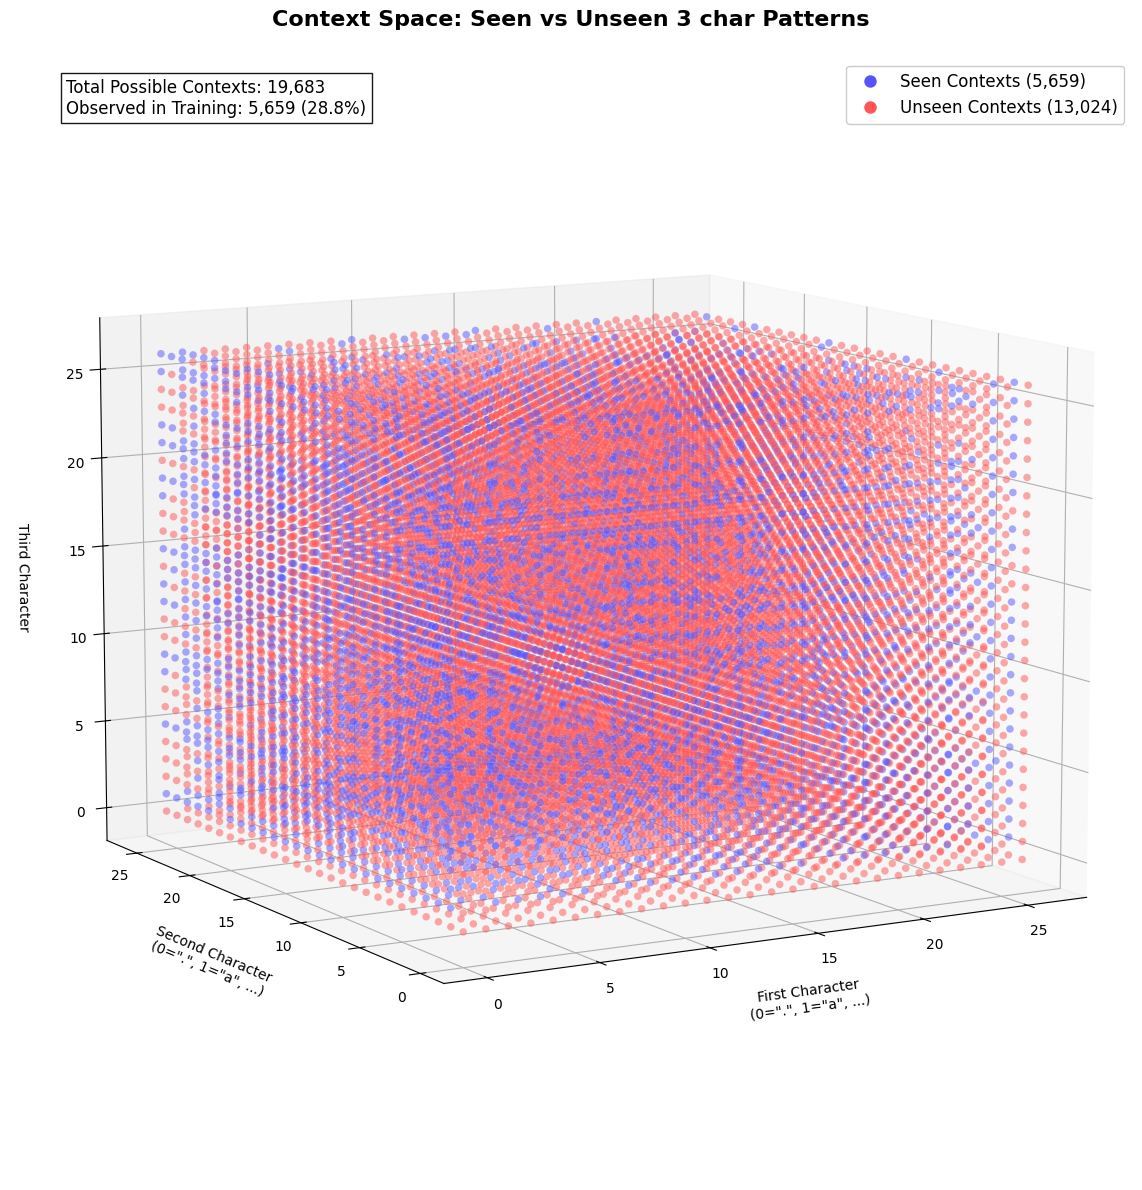

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import torch

seen_contexts = torch.unique(xs)
all_contexts = torch.arange(27**3)
is_seen = torch.isin(all_contexts, seen_contexts)

def index_to_3d(idx):
    c1 = idx // (27*27)
    idx = idx % (27*27)
    c2 = idx // 27
    c3 = idx % 27
    return c1, c2, c3

c1, c2, c3 = zip(*[index_to_3d(i) for i in range(27**3)])
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection='3d')
cmap = ListedColormap(['#ff5555', '#5555ff'])  # Bright colors

scatter = ax.scatter(
    c1, c2, c3,
    c=is_seen.numpy(),          # 0=unseen (red), 1=seen (blue)
    cmap=cmap,
    alpha=0.5,                  # Semi-transparent
    s=30,                       # Larger points
    edgecolor='w',              # White edges for contrast
    linewidth=0.1,
    depthshade=False            # Disable depth shading for clarity
)

seen_proxy = plt.Line2D([0], [0], linestyle='none', 
                      marker='o', markersize=10,
                      markerfacecolor='#5555ff',
                      markeredgecolor='w',
                      label='Seen Contexts (5,659)')

unseen_proxy = plt.Line2D([0], [0], linestyle='none', 
                        marker='o', markersize=10,
                        markerfacecolor='#ff5555',
                        markeredgecolor='w',
                        label='Unseen Contexts (13,024)')

ax.legend(handles=[seen_proxy, unseen_proxy], 
        loc='upper right',
        fontsize=12,
        framealpha=1)

ax.set_xlabel('First Character\n(0=".", 1="a", ...)', 
            fontsize=10, labelpad=15)
ax.set_ylabel('Second Character\n(0=".", 1="a", ...)', 
            fontsize=10, labelpad=15)
ax.set_zlabel('Third Character', 
            fontsize=10, labelpad=15)

ax.view_init(elev=10, azim=-120)  
ax.dist = 10  #
plt.tight_layout(pad=3.0)  

ax.mouse_init(rotate_btn=1, zoom_btn=3)

ax.grid(True, alpha=0.3)
plt.title('Context Space: Seen vs Unseen 3 char Patterns\n', 
        fontsize=16, fontweight='bold')

ax.text2D(0.05, 0.95, 
        f"Total Possible Contexts: {27**3:,}\n"
        f"Observed in Training: {len(seen_contexts):,} ({len(seen_contexts)/27**3:.1%})",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

## The Curse of Dimensionality
The paper by Bengio et al. (2003), "[<span style="color: #2b6cb0"><u>*A Neural Probabilistic Language Model*</u></span>](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)"

**The Problem**: Suppose we have a vocabulary of 50,000 words.  
- If we model 10-word sequences, the number of possible combinations is $50{,}000^{10}$—a **high-dimensional discrete space**.  
- Even with massive text corpora, most sequences will **never appear** in training data. For example, "*The purple refrigerator sang opera gracefully*" might never occur, making probability estimation impossible.  

This is the curse of dimensionality: the **exponential growth** of possible combinations in high-dimensional spaces makes learning statistically impossible

##### example from the Paper...  

1. **Learning distributed representations**:  
   - Instead of treating words as discrete "one-hot" vectors (e.g., 50,000 dimensions), words are mapped to **lower-dimensional embeddings** (e.g., 100-D).  
   - *Example*: Words like "cat" and "dog" have similar embeddings, capturing semantic relationships.  

2. **Sharing statistical strength**:  
   - Similar words share parameters in the embedding space. For example, if "*cat*" and "*kitten*" have similar embeddings, the model can generalize from "*The cat sat*" to "*The kitten sat*" without needing to see both phrases.  

3. **Avoiding exponential reliance on history**:  
   - Traditional n-gram models suffer because they explicitly model:
   $$P(\text{word}_t \mid \text{word}_{t-1}, \dots, \text{word}_{t-n})$$
   For $n=5$, this requires estimating probabilities for $50{,}000^5$ combinations.  
   - Neural networks instead **compress** this information into dense vectors and nonlinear transformations, reducing dimensionality.


## Word Representations in Vector Space

[<span style="color: #2b6cb0"><u>Tomas Mikolov paper</u></span>](https://arxiv.org/pdf/1301.3781) for the first of its kind to show word embeddings and how it can capture linguistic regularities. The paper showed that simple vector arithmetic could reveal relationships between words. 

e.g. To find a word that is similar to `small` in the same sense as `biggest` is similar to `big`, we can simply compute 

```python
vector (X) = vector(”biggest”) − vector(”big”) + vector(”small”). 
```

ADD a small note here
Then, we search in the vector space for the word closest to X measured by cosine distance

For words, images, or sentences, we often cannot hand-design the right features well enough. So the model learns a useful coordinate system for us. That learned coordinate is the embedding

Kings embedding: [-0.32307  -0.87616   0.21977   0.25268   0.22976   0.7388   -0.37954
 -0.35307  -0.84369  -1.1113   -0.30266   0.33178  -0.25113   0.30448
 -0.077491 -0.89815   0.092496 -1.1407   -0.58324   0.66869  -0.23122
 -0.95855   0.28262  -0.078848  0.75315   0.26584   0.3422   -0.33949
  0.95608   0.065641  0.45747   0.39835   0.57965   0.39267  -0.21851
  0.58795  -0.55999   0.63368  -0.043983 -0.68731  -0.37841   0.38026
  0.61641  -0.88269  -0.12346  -0.37928  -0.38318   0.23868   0.6685
 -0.43321  -0.11065   0.081723  1.1569    0.78958  -0.21223  -2.3211
 -0.67806   0.44561   0.65707   0.1045    0.46217   0.19912   0.25802
  0.057194  0.53443  -0.43133  -0.34311   0.59789  -0.58417   0.068995
  0.23944  -0.85181   0.30379  -0.34177  -0.25746  -0.031101 -0.16285
  0.45169  -0.91627   0.64521   0.73281  -0.22752   0.30226   0.044801
 -0.83741   0.55006  -0.52506  -1.7357    0.4751   -0.70487   0.056939
 -0.7132    0.089623  0.41394  -1.3363   -0.61915  -0.33089  -0.52881
  

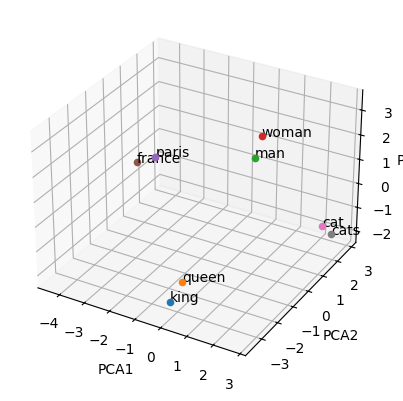

In [ ]:
import gensim.downloader as api
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

model = api.load("glove-wiki-gigaword-100")

def cosine_similarity(vec_a, vec_b):
    dot_product = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    return dot_product / (norm_a * norm_b)

pairs = [
    ("king", "king"),
    ("king", "queen"),
    ("king", "man"),
    ("woman", "queen"),
    ("paris", "france"),
    ("rome", "italy"),
    ("cat", "cats"),
    ("king", "cat"),
]

print("Kings embedding:", model["king"])

print("Cosine similarities:")
for a, b in pairs:
    sim = cosine_similarity(model[a], model[b])
    print(f"{a:>8} vs {b:<8}: {sim:.4f}")

words = ['king', 'queen', 'man', 'woman', 'paris', 'france', 'cat', 'cats']
word_vectors = [model[word] for word in words]
pca = PCA(n_components=3)
reduced_vectors = pca.fit_transform(word_vectors)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for word, vec in zip(words, reduced_vectors):
    ax.scatter(vec[0], vec[1], vec[2])
    ax.text(vec[0], vec[1], vec[2], word)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
plt.show()


#### Embedding Projector
Here is a good tool [<span style="color: #2b6cb0"><u>Embedding Projector</u></span>](https://projector.tensorflow.org/) for visualizing high-dimensional data like MINST and Word2vec